In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Start with first 100
# 3a-b. Create an ID for each machine (in this case, using a list)
list100 = []
for x in range(1, 101):
    df_temp = pd.read_csv(f"2013-8/{x}.csv", sep=";").rename(columns=str.strip)
    df_temp["machine_id"] = x
    list100.append(df_temp)
# 3c(i). Combine into a single dataframe
df100 = pd.concat(list100)
print(df100.shape)
print(df100.isna().sum())
# 3c(ii). Sort by machine_id then by timestamp
df100 = df100.sort_values(["machine_id", "Timestamp [ms]"])

(1024868, 12)
Timestamp [ms]                           0
CPU cores                                0
CPU capacity provisioned [MHZ]           0
CPU usage [MHZ]                          0
CPU usage [%]                            0
Memory capacity provisioned [KB]         0
Memory usage [KB]                        0
Disk read throughput [KB/s]              0
Disk write throughput [KB/s]             0
Network received throughput [KB/s]       0
Network transmitted throughput [KB/s]    0
machine_id                               0
dtype: int64


In [7]:
metrics = [c for c in df100.columns if c not in ["machine_id", "Timestamp [ms]", "datetime", "time_diff_s"]]
num_df = df100[metrics]
num_df.head()


,CPU cores,CPU capacity provisioned [MHZ],CPU usage [MHZ],CPU usage [%],Memory capacity provisioned [KB],Memory usage [KB],Disk read throughput [KB/s],Disk write throughput [KB/s],Network received throughput [KB/s],Network transmitted throughput [KB/s]
0,4,11703.99824,10912.027692,93.233333,67108864.0,6.129274e+06,0.133333,15981.600000,0.000000,2.133333
1,4,11703.99824,10890.570362,93.050000,67108864.0,6.755624e+06,1.333333,19137.333333,0.000000,2.600000
2,4,11703.99824,10434.114431,89.150000,67108864.0,8.947846e+06,2.533333,19974.933333,535.666667,23.933333
3,4,11703.99824,10539.450415,90.050000,67108864.0,1.879048e+07,5.466667,8791.800000,349.666667,5.466667
4,4,11703.99824,10951.041020,93.566667,67108864.0,9.305761e+06,5.400000,15679.533333,0.000000,2.066667


/opt/anaconda3/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/var/folders/5m/5427_2cj3r3500tg3_0ywsxm0000gn/T/ipykernel_96601/2924136889.py:23: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


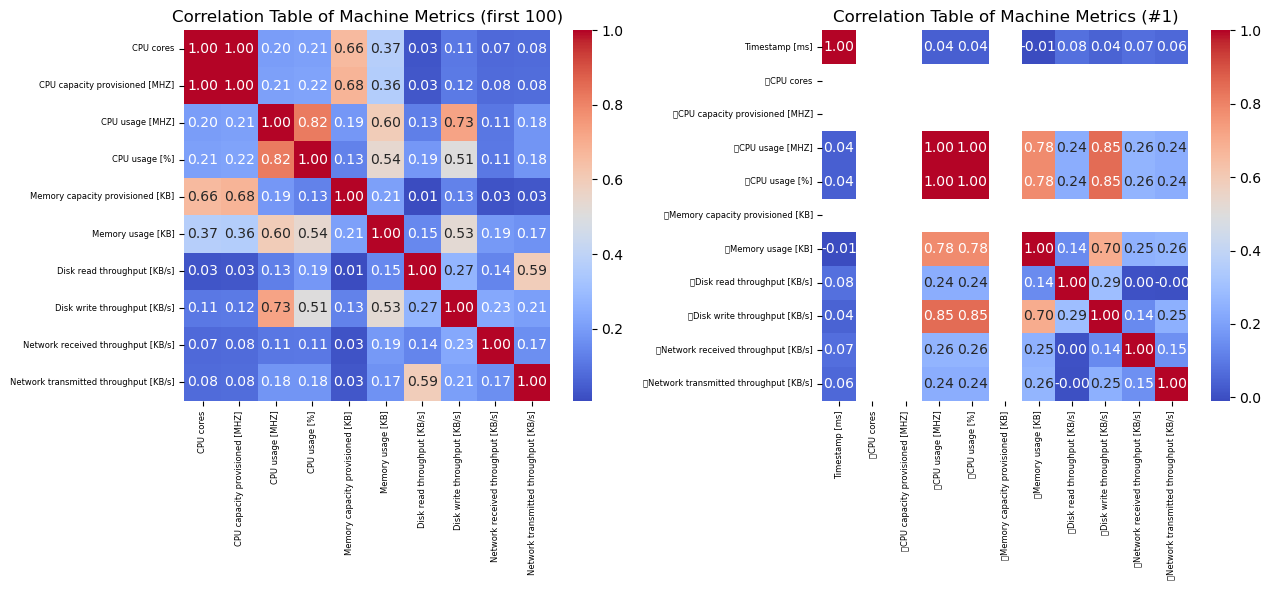

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

corr = num_df.corr()

N = 1
corr2 = pd.read_csv(f"2013-8/{N}.csv", sep=";")
corr2 = corr2.corr()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", ax=ax1)
ax1.set_title("Correlation Table of Machine Metrics (first 100)")
ax1.tick_params(axis="x", labelsize=6)
ax1.tick_params(axis="y", labelsize=6)

sns.heatmap(corr2, annot=True, cmap="coolwarm", fmt=".2f", ax=ax2)
ax2.set_title(f"Correlation Table of Machine Metrics (#{N})")
ax2.tick_params(axis="x", labelsize=6)
ax2.tick_params(axis="y", labelsize=6)

plt.tight_layout()
plt.show()
